# K-Means and K-Medoids Clustering Using the Wine Dataset

**Name:** Elkana Munganga  
**Course:** MSCS-634-M50 – Advanced Big Data and Data Mining  
**Assignment:** K-Means and K-Medoids Clustering Lab

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="class")

print("Dataset Shape:", X.shape)
print("\nFirst 5 Rows:")
display(X.head())

print("\nFeatures:")
print(list(wine.feature_names))

print("\nClass Distribution:")
print(y.value_counts().sort_index())

print("\nClass Names:")
for i, name in enumerate(wine.target_names):
    print(i, "=", name)

Dataset Shape: (178, 13)

First 5 Rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Features:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Class Distribution:
class
0    59
1    71
2    48
Name: count, dtype: int64

Class Names:
0 = class_0
1 = class_1
2 = class_2


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Standardized Dataset:")
display(X_scaled_df.head())

print("\nMean after standardization:")
print(X_scaled_df.mean().round(2))

print("\nStandard deviation after standardization:")
print(X_scaled_df.std(ddof=0).round(2))

Standardized Dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874



Mean after standardization:
alcohol                        -0.0
malic_acid                     -0.0
ash                            -0.0
alcalinity_of_ash              -0.0
magnesium                      -0.0
total_phenols                   0.0
flavanoids                     -0.0
nonflavanoid_phenols            0.0
proanthocyanins                -0.0
color_intensity                 0.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                        -0.0
dtype: float64

Standard deviation after standardization:
alcohol                         1.0
malic_acid                      1.0
ash                             1.0
alcalinity_of_ash               1.0
magnesium                       1.0
total_phenols                   1.0
flavanoids                      1.0
nonflavanoid_phenols            1.0
proanthocyanins                 1.0
color_intensity                 1.0
hue                             1.0
od280/od315_of_diluted_wines    1.0
proline      

In [5]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
ari_kmeans = adjusted_rand_score(y, kmeans_labels)

print("K-Means Results")
print("----------------")
print("Number of Clusters:", 3)
print("Silhouette Score:", round(silhouette_kmeans, 4))
print("Adjusted Rand Index (ARI):", round(ari_kmeans, 4))

print("\nCluster Distribution:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Results
----------------
Number of Clusters: 3
Silhouette Score: 0.2849
Adjusted Rand Index (ARI): 0.8975

Cluster Distribution:
0    65
1    51
2    62
Name: count, dtype: int64


### K-Means Results
I applied K-Means clustering with k = 3 because the Wine dataset contains three actual classes. The Silhouette Score measures how well the observations are grouped within their clusters, while the Adjusted Rand Index compares the predicted clusters with the actual Wine classes.

In [6]:
import numpy as np

def k_medoids(X, k=3, max_iter=100, random_state=42):
    rng = np.random.default_rng(random_state)

    # Select initial medoids
    medoid_indices = rng.choice(len(X), k, replace=False)

    for _ in range(max_iter):
        # Calculate distances to medoids
        distances = np.linalg.norm(
            X[:, np.newaxis] - X[medoid_indices],
            axis=2
        )

        labels = np.argmin(distances, axis=1)

        new_medoids = medoid_indices.copy()

        # Find best medoid within each cluster
        for cluster in range(k):
            cluster_indices = np.where(labels == cluster)[0]

            if len(cluster_indices) == 0:
                continue

            cluster_points = X[cluster_indices]

            pairwise_distances = np.linalg.norm(
                cluster_points[:, np.newaxis] -
                cluster_points[np.newaxis, :],
                axis=2
            )

            costs = pairwise_distances.sum(axis=1)
            new_medoids[cluster] = cluster_indices[np.argmin(costs)]

        if np.array_equal(medoid_indices, new_medoids):
            break

        medoid_indices = new_medoids

    # Final labels
    distances = np.linalg.norm(
        X[:, np.newaxis] - X[medoid_indices],
        axis=2
    )

    labels = np.argmin(distances, axis=1)

    return labels, medoid_indices


kmedoids_labels, medoid_indices = k_medoids(
    X_scaled,
    k=3,
    random_state=42
)

silhouette_kmedoids = silhouette_score(
    X_scaled,
    kmedoids_labels
)

ari_kmedoids = adjusted_rand_score(
    y,
    kmedoids_labels
)

print("K-Medoids Results")
print("-----------------")
print("Number of Clusters:", 3)
print("Silhouette Score:", round(silhouette_kmedoids, 4))
print("Adjusted Rand Index (ARI):", round(ari_kmedoids, 4))
print("Medoid Indices:", medoid_indices)

print("\nCluster Distribution:")
print(pd.Series(kmedoids_labels).value_counts().sort_index())

K-Medoids Results
-----------------
Number of Clusters: 3
Silhouette Score: 0.2676
Adjusted Rand Index (ARI): 0.7411
Medoid Indices: [106  35 148]

Cluster Distribution:
0    55
1    74
2    49
Name: count, dtype: int64


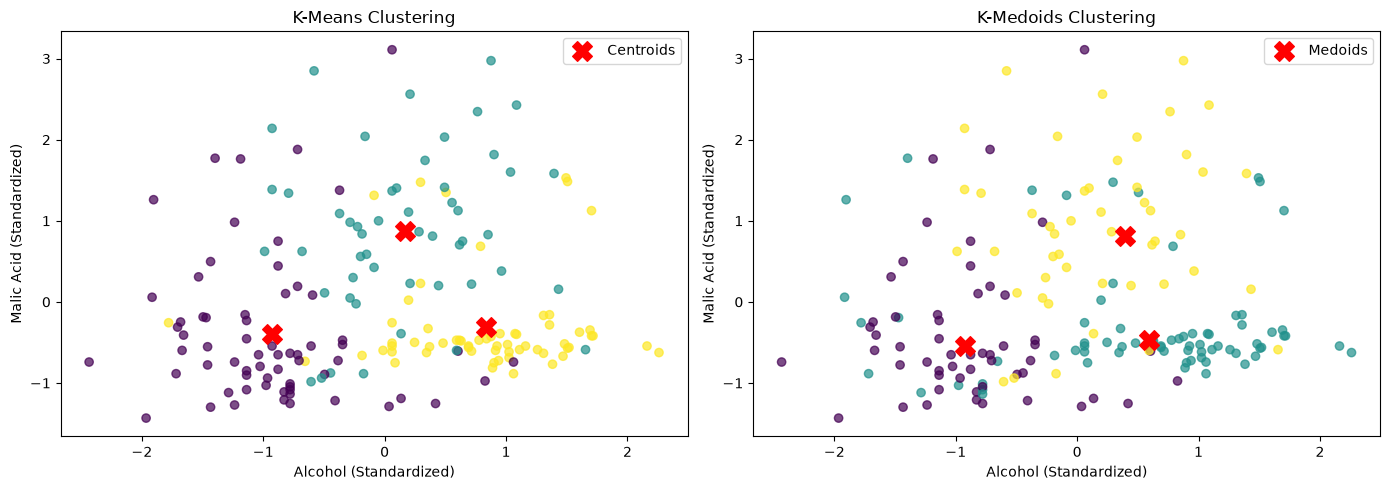

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means
axes[0].scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    alpha=0.7
)

axes[0].scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    c="red",
    label="Centroids"
)

axes[0].set_title("K-Means Clustering")
axes[0].set_xlabel("Alcohol (Standardized)")
axes[0].set_ylabel("Malic Acid (Standardized)")
axes[0].legend()


# K-Medoids
axes[1].scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmedoids_labels,
    cmap="viridis",
    alpha=0.7
)

axes[1].scatter(
    X_scaled[medoid_indices, 0],
    X_scaled[medoid_indices, 1],
    marker="X",
    s=200,
    c="red",
    label="Medoids"
)

axes[1].set_title("K-Medoids Clustering")
axes[1].set_xlabel("Alcohol (Standardized)")
axes[1].set_ylabel("Malic Acid (Standardized)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
results = pd.DataFrame({
    "Algorithm": ["K-Means", "K-Medoids"],
    "Silhouette Score": [
        silhouette_kmeans,
        silhouette_kmedoids
    ],
    "Adjusted Rand Index": [
        ari_kmeans,
        ari_kmedoids
    ]
})

results.round(4)

,Algorithm,Silhouette Score,Adjusted Rand Index
0,K-Means,0.2849,0.8975
1,K-Medoids,0.2676,0.7411


### Comparison and Observations

Both K-Means and K-Medoids were able to divide the Wine dataset into three clusters. The Silhouette Score shows how well-separated and compact the clusters are, while the Adjusted Rand Index shows how closely the generated clusters match the actual wine classes.

The algorithm with the higher Silhouette Score produced better-defined clusters, while the algorithm with the higher ARI produced clusters that more closely matched the actual classes. The scatter plots also show some overlap between clusters, meaning that the wine classes are not completely separated based on the two features displayed.

K-Means uses the average position of observations as the center of each cluster, while K-Medoids uses actual observations as cluster centers. K-Means may be preferable when computational efficiency is important, especially with larger datasets. K-Medoids may be preferable when the dataset contains outliers because medoids are generally less sensitive to extreme values.